c:\laragon\bin\python\python-3.10\lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.2.1) or chardet (7.4.3)/charset_normalizer (3.3.2) doesn't match a supported version!
  warnings.warn(


c:\laragon\bin\python\python-3.10\lib\site-packages\keras\src\saving\saving_lib.py:794: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 6 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


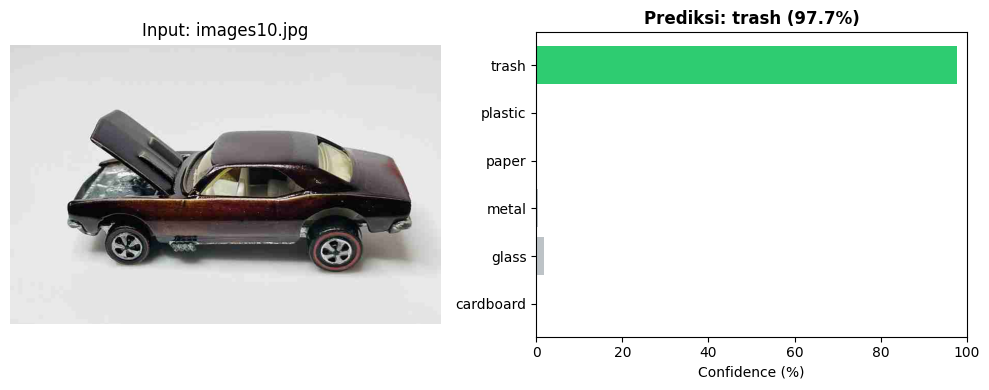

Hasil   : TRASH
Yakin   : 97.67%


In [1]:
from tensorflow.keras.models import load_model
import numpy as np
import cv2
import matplotlib.pyplot as plt

# =============================================
# LOAD MODEL (skip kalau model sudah ada di memori)
# =============================================
model = load_model('../content/garbage_classifier_mobilenetv2.keras')
CLASSES = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

# =============================================
# GANTI PATH INI dengan lokasi foto kamu
# =============================================
TEST_IMAGE = 'images10.jpg'   # <-- ganti ini

# Baca & prediksi
img     = cv2.imread(TEST_IMAGE)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_res = cv2.resize(img_rgb, (224, 224))
img_in  = np.expand_dims(img_res.astype('float32') / 255.0, axis=0)

preds      = model.predict(img_in, verbose=0)[0]
pred_class = CLASSES[np.argmax(preds)]
confidence = np.max(preds) * 100

# Tampilkan hasil
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img_rgb)
axes[0].set_title(f'Input: {TEST_IMAGE}')
axes[0].axis('off')

axes[1].barh(CLASSES, preds * 100, 
             color=['#2ecc71' if c == pred_class else '#bdc3c7' for c in CLASSES])
axes[1].set_xlabel('Confidence (%)')
axes[1].set_title(f'Prediksi: {pred_class} ({confidence:.1f}%)', fontweight='bold')
axes[1].set_xlim([0, 100])

plt.tight_layout()
plt.show()

print(f'Hasil   : {pred_class.upper()}')
print(f'Yakin   : {confidence:.2f}%')